In [1]:
pip install einops

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: nb-black 1.0.7 has a non-standard dependency specifier black>='19.3'; python_version >= "3.6". pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of nb-black or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 85.5 MB/s eta 0:00:00a 0:00:01
DEPRECATION: nb-black 1.0.7 has a non-standard dependency specifier black>='19.3'; python_version >= "3.6". pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of nb-black or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install numpy==1.24.2  # or another version within the compatible range



Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: nb-black 1.0.7 has a non-standard dependency specifier black>='19.3'; python_version >= "3.6". pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of nb-black or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [4]:
import os

# Set the environment variable within Python
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'



# Data Loading

In [5]:
import tqdm
import random
import pathlib
import itertools
import collections

import cv2
import einops
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
tf.config.threading.set_intra_op_parallelism_threads(3)
tf.config.threading.set_inter_op_parallelism_threads(3)


from tensorflow import keras
from tensorflow.keras import layers

2024-05-02 09:26:45.620735: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-02 09:26:46.799021: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-02 09:26:48.304605: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-02 09:27:01.973431: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-05-02 09:27:11.047734: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://w

In [6]:
DATASET_DIR = pathlib.Path('FINAL DATASET')

In [7]:
def get_files_per_class(directory):
    """
    Get files for each class in the dataset directory.

    Args:
        directory: The root directory of the JUDO dataset.
    
    Returns:
        A dictionary with class names as keys and lists of file paths as values.
    """
    files_for_class = collections.defaultdict(list)
    for class_dir in directory.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name
            files_for_class[class_name].extend(class_dir.glob('*.avi'))  # Modify the extension if needed
    return files_for_class

# def split_files_for_training(files_for_class, train_split=0.7, val_split=0.15, test_split=0.15):
#     """
#     Split the files into training, validation, and test sets.

#     Args:
#         files_for_class: A dictionary with class names as keys and lists of file paths as values.
#         train_split: Proportion of the dataset to include in the train split.
#         val_split: Proportion of the dataset to include in the val split.
#         test_split: Proportion of the dataset to include in the test split.
    
#     Returns:
#         Three dictionaries, each representing train, validation, and test splits.
#     """
#     train_files, val_files, test_files = {}, {}, {}
#     for class_name, files in files_for_class.items():
#         random.shuffle(files)
#         total_files = len(files)
#         train_end = int(total_files * train_split)
#         val_end = train_end + int(total_files * val_split)
#         train_files[class_name] = files[:train_end]
#         val_files[class_name] = files[train_end:val_end]
#         test_files[class_name] = files[val_end:]
#     return train_files, val_files, test_files

def format_frames(frame, output_size):
    """
    Pad and resize an image from a video.

    Args:
    frame: Image that needs to resized and padded.
    output_size: Pixel size of the output frame image.

    Return:
    Formatted frame with padding of specified output size.
    """
    frame = tf.image.convert_image_dtype(frame, tf.float32)
    frame = tf.image.resize_with_pad(frame, *output_size)
    return frame

def frames_from_video_file(video_path, n_frames, output_size=(224, 224), frame_step=15):
    """
    Creates frames from each video file present for each category.

    Args:
    video_path: File path to the video.
    n_frames: Number of frames to be created per video file.
    output_size: Pixel size of the output frame image.

    Return:
    An NumPy array of frames in the shape of (n_frames, height, width, channels).
    """
    result = []
    src = cv2.VideoCapture(str(video_path))

    video_length = src.get(cv2.CAP_PROP_FRAME_COUNT)

    need_length = 1 + (n_frames - 1) * frame_step

    if need_length > video_length:
        start = 0
    else:
        max_start = video_length - need_length
        start = random.randint(0, max_start + 1)

    src.set(cv2.CAP_PROP_POS_FRAMES, start)
    ret, frame = src.read()
    if ret:
        result.append(format_frames(frame, output_size))

    for _ in range(n_frames - 1):
        for _ in range(frame_step):
            ret, frame = src.read()
            if not ret:
                break
        if ret:
            frame = format_frames(frame, output_size)
            result.append(frame)
        else:
            result.append(np.zeros_like(result[0]))

    src.release()
    result = np.array(result)[..., [2, 1, 0]]

    return result


class FrameGenerator:
    def __init__(self, path, n_frames, training=False):
        self.path = path
        self.n_frames = n_frames
        self.training = training
        self.class_names = sorted(set(p.name.split('_')[0] for p in self.path.iterdir() if p.is_dir()))
        self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))

    def __call__(self):
        for class_dir in self.path.iterdir():
            if not class_dir.is_dir():
                continue
            class_name = class_dir.name.split('_')[0]
            class_id = self.class_ids_for_name[class_name]
            for video_path in class_dir.glob('*.mp4'):  # Use appropriate file extension
                video_frames = frames_from_video_file(video_path, self.n_frames)
                yield video_frames, class_id


In [8]:
files_for_class = get_files_per_class(DATASET_DIR)

In [9]:
n_frames = 30
batch_size = 8

import pathlib

output_signature = (tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32),
                    tf.TensorSpec(shape=(), dtype=tf.int32))


# Define the paths to your dataset
DATASET_DIR = pathlib.Path('FINAL DATASET/ALL')  # Adjust this path if necessary

# Create instances of the FrameGenerator for train and evaluate
train_gen = FrameGenerator(DATASET_DIR / 'train', n_frames, training=True)
val_gen = FrameGenerator(DATASET_DIR / 'evaluate', n_frames)

# Create the datasets
train_ds = tf.data.Dataset.from_generator(train_gen, output_signature=output_signature).batch(batch_size)
val_ds = tf.data.Dataset.from_generator(val_gen, output_signature=output_signature).batch(batch_size)


# Generate a list of labels from the training generator
labels = list(train_gen.class_ids_for_name.keys())


# 3D-CNN Model Creation

In [10]:
HEIGHT = 224
WIDTH = 224
n_classes = 3  

In [11]:
class Conv2Plus1D(keras.layers.Layer):
  def __init__(self, filters, kernel_size, padding):
    """
      A sequence of convolutional layers that first apply the convolution operation over the
      spatial dimensions, and then the temporal dimension. 
    """
    super().__init__()
    self.seq = keras.Sequential([  
        # Spatial decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(1, kernel_size[1], kernel_size[2]),
                      padding=padding),
        # Temporal decomposition
        layers.Conv3D(filters=filters, 
                      kernel_size=(kernel_size[0], 1, 1),
                      padding=padding)
        ])
  
  def call(self, x):
    return self.seq(x)

In [12]:
class ResidualMain(keras.layers.Layer):
  """
    Residual block of the model with convolution, layer normalization, and the
    activation function, ReLU.
  """
  def __init__(self, filters, kernel_size):
    super().__init__()
    self.seq = keras.Sequential([
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization(),
        layers.ReLU(),
        Conv2Plus1D(filters=filters, 
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization()
    ])
    
  def call(self, x):
    return self.seq(x)

In [13]:
class Project(keras.layers.Layer):
  """
    Project certain dimensions of the tensor as the data is passed through different 
    sized filters and downsampled. 
  """
  def __init__(self, units):
    super().__init__()
    self.seq = keras.Sequential([
        layers.Dense(units),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

In [14]:
def add_residual_block(input, filters, kernel_size):
  """
    Add residual blocks to the model. If the last dimensions of the input data
    and filter size does not match, project it such that last dimension matches.
  """
  out = ResidualMain(filters, 
                     kernel_size)(input)
  
  res = input
  # Using the Keras functional APIs, project the last dimension of the tensor to
  # match the new filter size
  if out.shape[-1] != input.shape[-1]:
    res = Project(out.shape[-1])(res)

  return layers.add([res, out])

In [15]:
class ResizeVideo(keras.layers.Layer):
  def __init__(self, height, width):
    super().__init__()
    self.height = height
    self.width = width
    self.resizing_layer = layers.Resizing(self.height, self.width)

  def call(self, video):
    """
      Use the einops library to resize the tensor.  
      
      Args:
        video: Tensor representation of the video, in the form of a set of frames.
      
      Return:
        A downsampled size of the video according to the new height and width it should be resized to.
    """
    # b stands for batch size, t stands for time, h stands for height, 
    # w stands for width, and c stands for the number of channels.
    old_shape = einops.parse_shape(video, 'b t h w c')
    images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
    images = self.resizing_layer(images)
    videos = einops.rearrange(
        images, '(b t) h w c -> b t h w c',
        t = old_shape['t'])
    return videos

In [16]:
input_shape = (None, 10, HEIGHT, WIDTH, 3)
input = layers.Input(shape=(input_shape[1:]))
x = input

x = Conv2Plus1D(filters=16, kernel_size=(3, 7, 7), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = ResizeVideo(HEIGHT // 2, WIDTH // 2)(x)

# Block 1
x = add_residual_block(x, 16, (3, 3, 3))
x = ResizeVideo(HEIGHT // 4, WIDTH // 4)(x)

# Block 2
x = add_residual_block(x, 32, (3, 3, 3))
x = ResizeVideo(HEIGHT // 8, WIDTH // 8)(x)

# Block 3
x = add_residual_block(x, 64, (3, 3, 3))
x = ResizeVideo(HEIGHT // 16, WIDTH // 16)(x)

# Block 4
x = add_residual_block(x, 128, (3, 3, 3))

x = layers.GlobalAveragePooling3D()(x)
x = layers.Flatten()(x)
x = layers.Dense(n_classes)(x)

model = keras.Model(input, x)

In [17]:
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_plus1d        │ (None, 10, 224,   │      3,152 │ input_layer[0][0] │
│ (Conv2Plus1D)       │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 224,   │         64 │ conv2_plus1d[0][… │
│ (BatchNormalizatio… │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 10, 224,   │          0 │ batch_normalizat… │
│                     │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_video        │ (None, 10, 112,   │          0 │ re_lu[0][0]       │
│ (ResizeVideo)       │ 112, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_main       │ (None, 10, 112,   │      6,272 │ resize_video[0][… │
│ (ResidualMain)      │ 112, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 112,   │          0 │ resize_video[0][… │
│                     │ 112, 16)          │            │ residual_main[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_video_1      │ (None, 10, 56,    │          0 │ add[0][0]         │
│ (ResizeVideo)       │ 56, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ project (Project)   │ (None, 10, 56,    │        608 │ resize_video_1[0… │
│                     │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_main_1     │ (None, 10, 56,    │     20,224 │ resize_video_1[0… │
│ (ResidualMain)      │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 56,    │          0 │ project[0][0],    │
│                     │ 56, 32)           │            │ residual_main_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_video_2      │ (None, 10, 28,    │          0 │ add_1[0][0]       │
│ (ResizeVideo)       │ 28, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ project_1 (Project) │ (None, 10, 28,    │      2,240 │ resize_video_2[0… │
│                     │ 28, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_main_2     │ (None, 10, 28,    │     80,384 │ resize_video_2[0… │
│ (ResidualMain)      │ 28, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 10, 28,    │          0 │ project_1[0][0],  │
│                     │ 28, 64)           │            │ residual_main_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_video_3      │ (None, 10, 14,    │          0 │ add_2[0][0]       │
│ (ResizeVideo)       │ 14, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ project_2 (Project) │ (None, 10, 14,    │      8,576 │ resize_video_3[0

 Total params: 442,419 (1.69 MB)

 Trainable params: 442,387 (1.69 MB)

 Non-trainable params: 32 (128.00 B)

In [18]:
model.build(input_shape)

# Training the Model

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Compile the model
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
    metrics=['accuracy']
)

history = model.fit(x = train_ds,
                    epochs = 10, 
                    validation_data = val_ds)

Epoch 1/10
    169/Unknown 3079s 18s/step - accuracy: 0.8988 - loss: 0.8760

2024-05-02 10:18:31.219328: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/share/pkg.7/python3/3.10.5/install/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


169/169 ━━━━━━━━━━━━━━━━━━━━ 3206s 19s/step - accuracy: 0.8989 - loss: 0.8747 - val_accuracy: 0.2178 - val_loss: 14.8468
Epoch 2/10


2024-05-02 10:20:38.550010: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.6957 - loss: 3.9429 

...

2024-05-02 17:31:50.912484: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.3752 - loss: 1.7502 

2024-05-02 18:23:46.143905: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


169/169 ━━━━━━━━━━━━━━━━━━━━ 3239s 19s/step - accuracy: 0.3766 - loss: 1.7460 - val_accuracy: 0.2178 - val_loss: 2.7906


2024-05-02 18:25:49.431583: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


# Visulaizing the Results

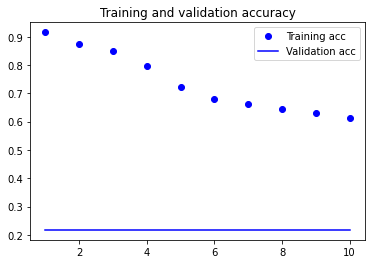

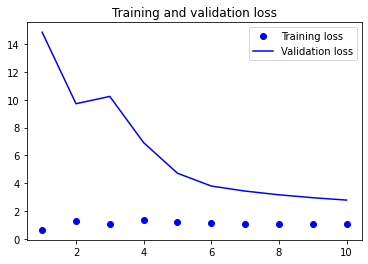

In [20]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

plot_training_history(history)

# Evaluate the model

In [21]:
model.evaluate(val_ds, return_dict=True)

26/26 ━━━━━━━━━━━━━━━━━━━━ 122s 5s/step - accuracy: 0.5135 - loss: 1.8643


2024-05-02 18:27:52.506890: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


{'accuracy': 0.21782177686691284, 'loss': 2.7906546592712402}

In [22]:
def get_actual_predicted_labels(dataset): 
  """
    Create a list of actual ground truth values and the predictions from the model.

    Args:
      dataset: An iterable data structure, such as a TensorFlow Dataset, with features and labels.

    Return:
      Ground truth and predicted values for a particular dataset.
  """
  actual = [labels for _, labels in dataset.unbatch()]
  predicted = model.predict(dataset)

  actual = tf.stack(actual, axis=0)
  predicted = tf.concat(predicted, axis=0)
  predicted = tf.argmax(predicted, axis=1)

  return actual, predicted

In [23]:
def plot_confusion_matrix(actual, predicted, labels, ds_type):
  cm = tf.math.confusion_matrix(actual, predicted)
  ax = sns.heatmap(cm, annot=True, fmt='g')
  sns.set(rc={'figure.figsize':(12, 12)})
  sns.set(font_scale=1.4)
  ax.set_title('Confusion matrix of action recognition for ' + ds_type)
  ax.set_xlabel('Predicted Action')
  ax.set_ylabel('Actual Action')
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(labels)
  ax.yaxis.set_ticklabels(labels)

In [24]:
fg = train_gen
labels = list(fg.class_ids_for_name.keys())
labels

['Osoto Gari', 'Seoi nage', 'Uchi Mata']

In [25]:
actual, predicted = get_actual_predicted_labels(train_ds)
plot_confusion_matrix(actual, predicted, labels, 'training')

2024-05-02 18:35:10.396289: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


ValueError: Input 0 of layer "functional_17" is incompatible with the layer: expected shape=(None, 10, 224, 224, 3), found shape=(8, 30, 224, 224, 3)

In [ ]:
actual, predicted = get_actual_predicted_labels(val_ds)
plot_confusion_matrix(actual, predicted, labels, 'evaluate')

In [ ]:
def calculate_classification_metrics(y_actual, y_pred, labels):
  """
    Calculate the precision and recall of a classification model using the ground truth and
    predicted values. 

    Args:
      y_actual: Ground truth labels.
      y_pred: Predicted labels.
      labels: List of classification labels.

    Return:
      Precision and recall measures.
  """
  cm = tf.math.confusion_matrix(y_actual, y_pred)
  tp = np.diag(cm) # Diagonal represents true positives
  precision = dict()
  recall = dict()
  for i in range(len(labels)):
    col = cm[:, i]
    fp = np.sum(col) - tp[i] # Sum of column minus true positive is false negative
    
    row = cm[i, :]
    fn = np.sum(row) - tp[i] # Sum of row minus true positive, is false negative
    
    precision[labels[i]] = tp[i] / (tp[i] + fp) # Precision 
    
    recall[labels[i]] = tp[i] / (tp[i] + fn) # Recall
  
  return precision, recall

In [ ]:
precision, recall = calculate_classification_metrics(actual, predicted, labels) # Test dataset

In [ ]:
print("Precision_Eval:", precision)
print("Recall_Eval:", recall)

In [ ]:
keras.utils.plot_model(model, expand_nested=False, dpi=60, show_shapes=True)


In [26]:
from tensorflow.keras.models import load_model
model.save('3D-CNN.keras')  # explicitly choose HDF5 format
